In [1]:
import os, json, h5py, zipfile, io, random
from pathlib import Path
from PIL import Image as PILImage

PROJECT = Path("/Users/mike/Documents/GitHub/non_sn/app-11-dl-on-gcp/naive-scene-graphs")
DATA = PROJECT / "data"
IMAGES = Path("/Users/mike/Documents/GitHub/non_sn/app-11-dl-on-gcp/img")
random.seed(42)

with h5py.File(DATA / "vg150/VG-SGG.h5", "r") as f:
    boxes = f["boxes_1024"][:]
    labels = f["labels"][:].flatten()
    first_b = f["img_to_first_box"][:]
    last_b = f["img_to_last_box"][:]

with open(DATA / "vg150/h5_to_vg_mapping.json") as f:
    h5_to_vg = json.load(f)
with open(DATA / "vg150/annotations/image_data.json") as f:
    id_to_url = {item["image_id"]: item["url"] for item in json.load(f)}
id_to_folder = {vid: url.split("/")[-2] for vid, url in id_to_url.items()}
with open(DATA / "vg150/VG-SGG-dicts.json") as f:
    d = json.load(f)
idx_label = {int(k): v for k, v in d["idx_to_label"].items()}

zip1 = zipfile.ZipFile(IMAGES / "images.zip", "r")
zip2 = zipfile.ZipFile(IMAGES / "images2.zip", "r")
zips = {"VG_100K": zip1, "VG_100K_2": zip2}

print(f"loaded. {len(boxes)} boxes, {len(h5_to_vg)} images")


loaded. 1145398 boxes, 108073 images


VG 2335177: arm (25x36px)


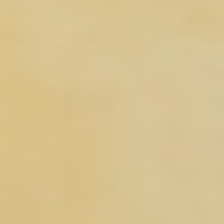


VG 2407651: table (366x372px)


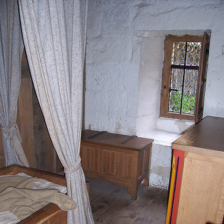


VG 3279: window (48x74px)


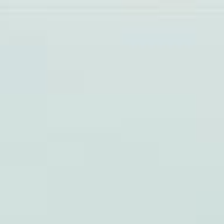


VG 2321185: cap (47x42px)


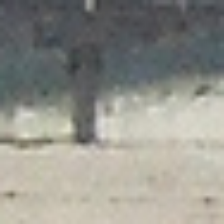


VG 2385206: glass (54x94px)


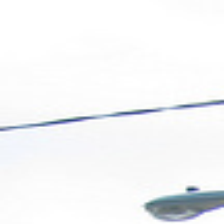


VG 2389352: ear (103x48px)


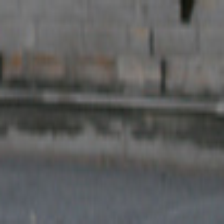


VG 2392303: arm (42x27px)


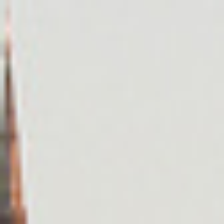


VG 2403773: food (248x152px)


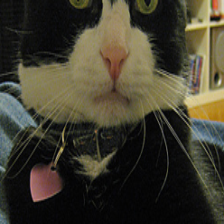

In [2]:
# pick a few images and show their crops

test_imgs = random.sample(range(len(h5_to_vg)), 8)

for img_idx in test_imgs:
    vg_id = h5_to_vg[img_idx]
    folder = id_to_folder.get(vg_id, "VG_100K")
    zf = zips.get(folder)
    if zf is None: continue

    img_name = f"{folder}/{vg_id}.jpg"
    if img_name not in zf.namelist(): continue

    s, e = first_b[img_idx], last_b[img_idx] + 1
    if e <= s: continue

    img_bytes = zf.read(img_name)
    img = PILImage.open(io.BytesIO(img_bytes)).convert("RGB")
    w, h = img.size

    box_idx = random.randint(s, e - 1)
    xc, yc, bw, bh = boxes[box_idx]
    x1 = int(max(0, xc - bw/2) / 1024 * w)
    y1 = int(max(0, yc - bh/2) / 1024 * h)
    x2 = int(min(1024, xc + bw/2) / 1024 * w)
    y2 = int(min(1024, yc + bh/2) / 1024 * h)

    crop = img.crop((x1, y1, x2, y2))
    crop = crop.resize((224, 224), PILImage.BILINEAR)

    label = int(labels[box_idx])
    name = idx_label.get(label, f"id_{label}")
    print(f"VG {vg_id}: {name} ({x2-x1}x{y2-y1}px)")
    display(crop)
    print()


VG 2335177: (500, 333), 10 boxes


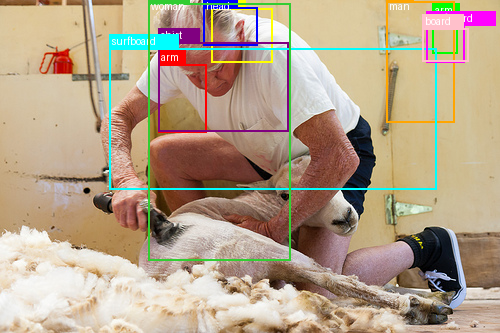

In [3]:
# show the full image with its boxes for one example

img_idx = test_imgs[0]
vg_id = h5_to_vg[img_idx]
folder = id_to_folder.get(vg_id, "VG_100K")
zf = zips[folder]
img_name = f"{folder}/{vg_id}.jpg"
img = PILImage.open(io.BytesIO(zf.read(img_name))).convert("RGB")
w, h = img.size
s, e = first_b[img_idx], last_b[img_idx] + 1

from PIL import ImageDraw
draw = ImageDraw.Draw(img, "RGBA")
for box_idx in range(s, min(s+10, e)):
    xc, yc, bw, bh = boxes[box_idx]
    x1 = int(max(0, xc - bw/2) / 1024 * w)
    y1 = int(max(0, yc - bh/2) / 1024 * h)
    x2 = int(min(1024, xc + bw/2) / 1024 * w)
    y2 = int(min(1024, yc + bh/2) / 1024 * h)
    lid = int(labels[box_idx])
    name = idx_label.get(lid, "?")

    colors = ["red","lime","yellow","blue","orange","purple",
              "cyan","magenta","limegreen","pink"]
    c = colors[(box_idx-s) % len(colors)]
    draw.rectangle([x1, y1, x2, y2], outline=c, width=2)
    draw.rectangle([x1, max(0, y1-14), x1+len(name)*7+6, y1], fill=c)
    draw.text((x1+3, max(0, y1-13)), name, fill="white")

print(f"VG {vg_id}: {img.size}, {e-s} boxes")
display(img)


In [4]:
# close zips
zip1.close()
zip2.close()
